CREATE CLEAN DATAFRAME

In [24]:
import pandas as pd

df = pd.read_csv("datasets/train.csv")

In [2]:
df = df[[
    "Mental Fatigue Score",
    "Resource Allocation",
    "Burn Rate"
]]

REMOVE EMPTY VALUES

In [3]:
df.dropna(inplace=True)

VERIFY DATA

In [4]:
print(df.head())

print(df.info())

   Mental Fatigue Score  Resource Allocation  Burn Rate
0                   3.8                  3.0       0.16
1                   5.0                  2.0       0.36
3                   2.6                  1.0       0.20
4                   6.9                  7.0       0.52
5                   3.6                  4.0       0.29
<class 'pandas.core.frame.DataFrame'>
Index: 18590 entries, 0 to 22749
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Mental Fatigue Score  18590 non-null  float64
 1   Resource Allocation   18590 non-null  float64
 2   Burn Rate             18590 non-null  float64
dtypes: float64(3)
memory usage: 580.9 KB
None


FEATURES & TARGET

In [5]:
X = df[[
    "Mental Fatigue Score",
    "Resource Allocation"
]]

y = df["Burn Rate"]

TRAIN TEST SPLIT

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

LINEAR REGRESSION

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

PREDICT

In [8]:
predictions = model.predict(X_test)

EVALUATE

In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, predictions))

print("R2 Score:", r2_score(y_test, predictions))

MAE: 0.045942267786470294
R2 Score: 0.9188297377844094


VISUALIZE PREDICTIONS

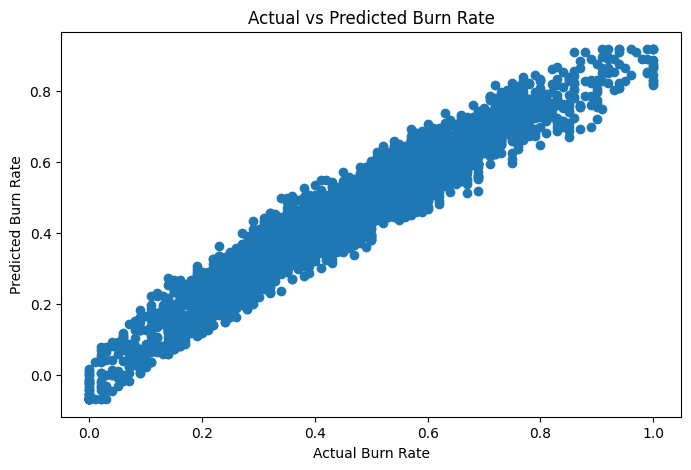

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Burn Rate")

plt.ylabel("Predicted Burn Rate")

plt.title("Actual vs Predicted Burn Rate")

plt.show()

Burn Rate Distribution

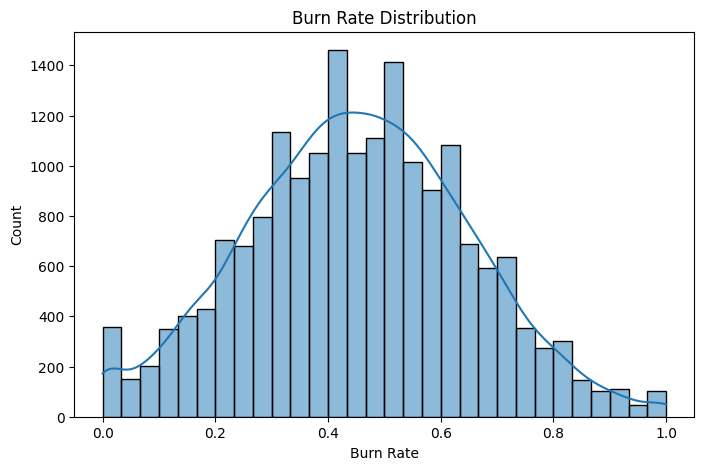

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(df["Burn Rate"], bins=30, kde=True)

plt.title("Burn Rate Distribution")

plt.xlabel("Burn Rate")

plt.ylabel("Count")

plt.show()

Mental Fatigue vs Burn Rate

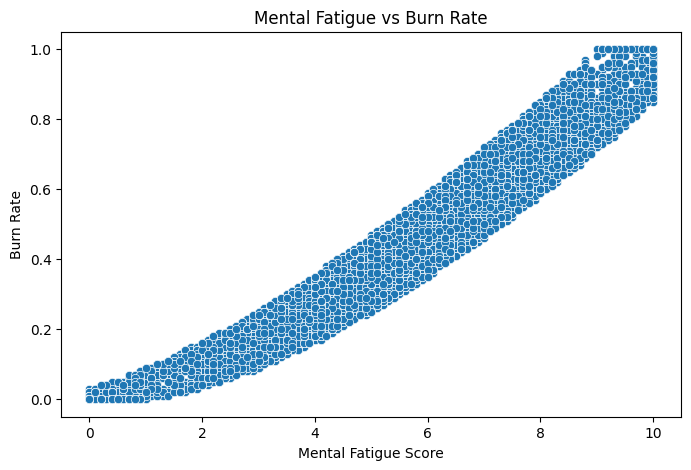

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Mental Fatigue Score"],
    y=df["Burn Rate"]
)

plt.title("Mental Fatigue vs Burn Rate")

plt.xlabel("Mental Fatigue Score")

plt.ylabel("Burn Rate")

plt.show()

Resource Allocation vs Burn Rate

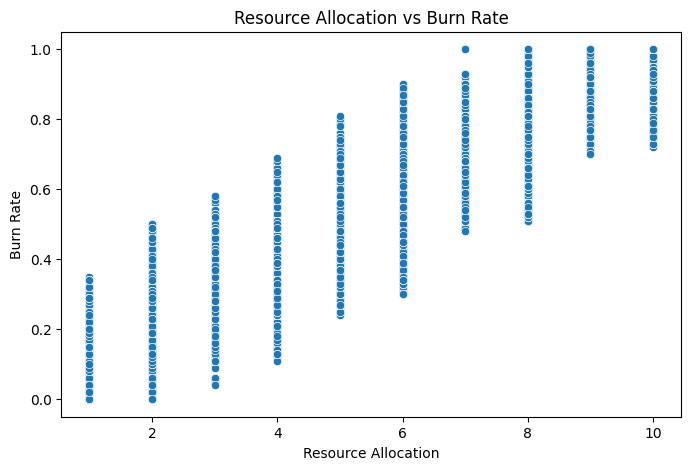

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Resource Allocation"],
    y=df["Burn Rate"]
)

plt.title("Resource Allocation vs Burn Rate")

plt.xlabel("Resource Allocation")

plt.ylabel("Burn Rate")

plt.show()

Correlation Heatmap

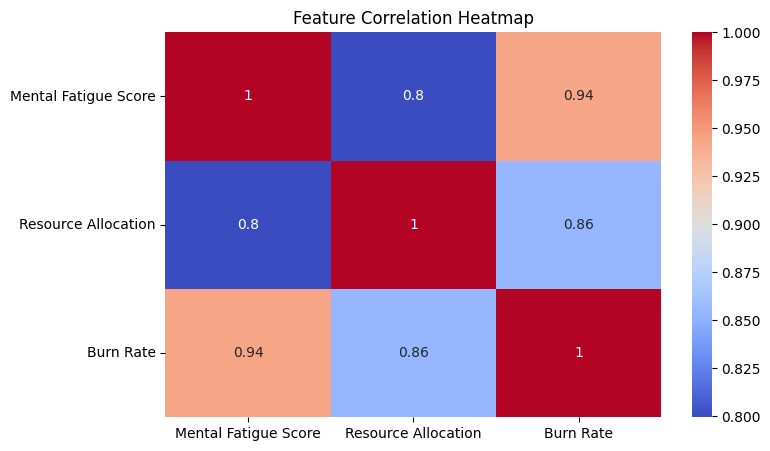

In [15]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

Burnout Risk Categories

In [16]:
#create Risk Lables
def risk_level(rate):
    if rate < 0.3:
        return "Low"
    elif rate < 0.6:
        return "Medium"
    else:
        return "High"

df["Risk Level"] = df["Burn Rate"].apply(risk_level)

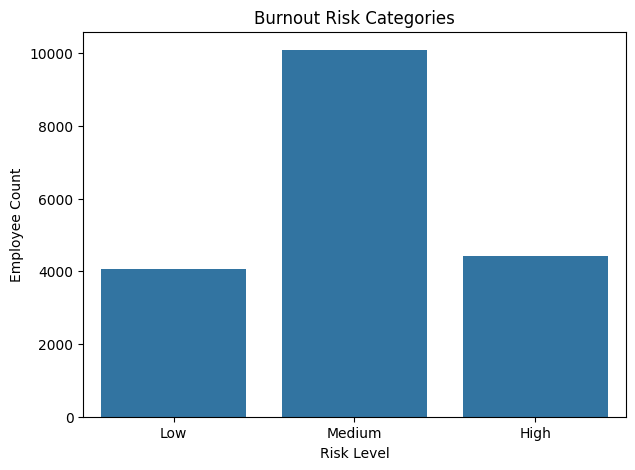

In [17]:
#Visualize Categories
plt.figure(figsize=(7,5))

sns.countplot(x=df["Risk Level"])

plt.title("Burnout Risk Categories")

plt.xlabel("Risk Level")

plt.ylabel("Employee Count")

plt.show()

Boxplot Analysis

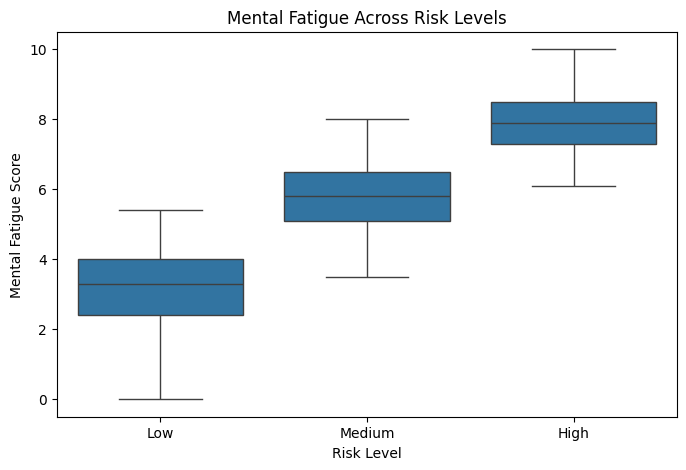

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Risk Level"],
    y=df["Mental Fatigue Score"]
)

plt.title("Mental Fatigue Across Risk Levels")

plt.show()

Pairplot

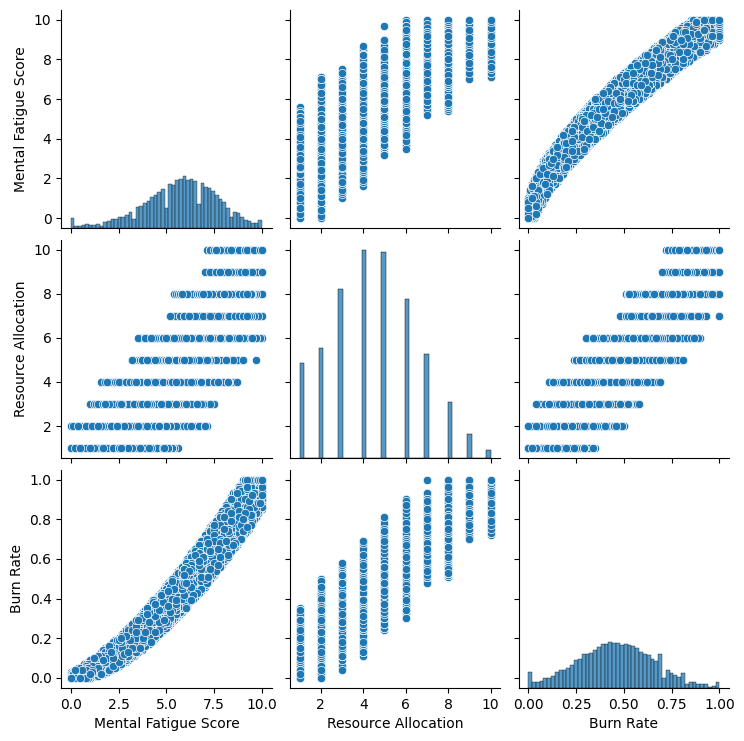

In [19]:
sns.pairplot(df[
    [
        "Mental Fatigue Score",
        "Resource Allocation",
        "Burn Rate"
    ]
])

plt.show()

KDE Plot (Smooth Distribution)

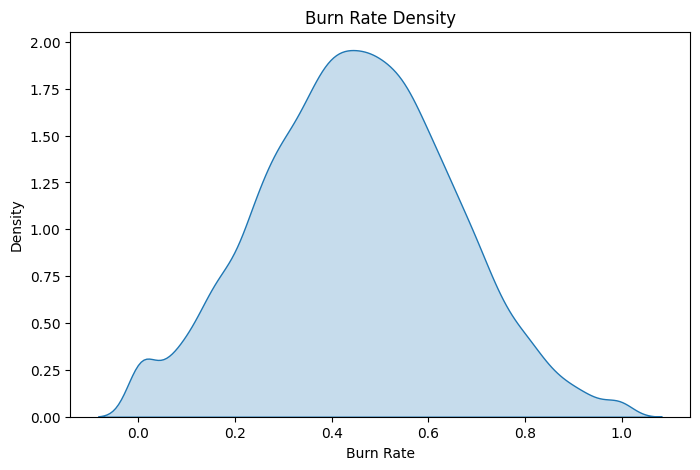

In [20]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    df["Burn Rate"],
    fill=True
)

plt.title("Burn Rate Density")

plt.show()

Feature Importance Style Graph

In [21]:
correlation = df.corr(numeric_only=True)["Burn Rate"]

correlation = correlation.sort_values(ascending=False)

print(correlation)

Burn Rate               1.000000
Mental Fatigue Score    0.944389
Resource Allocation     0.855005
Name: Burn Rate, dtype: float64


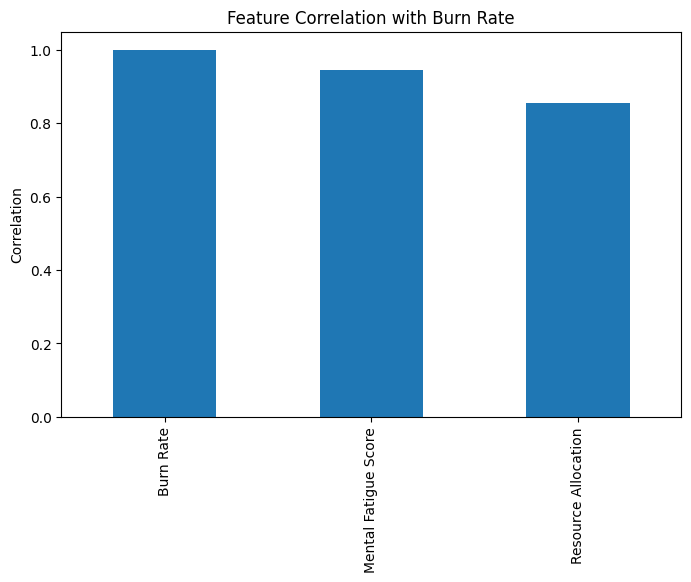

In [22]:
#Visualize Correlation Strength
plt.figure(figsize=(8,5))

correlation.plot(kind="bar")

plt.title("Feature Correlation with Burn Rate")

plt.ylabel("Correlation")

plt.show()

In [ ]:
# Insight:
# Higher mental fatigue is strongly associated with increased burnout levels.